In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import plotly.express as px
from scipy.stats import boxcox

In [2]:
pwd

'C:\\Users\\Yudith\\Desktop\\Análisis de Datos\\PHARMA'

In [3]:
df = pd.read_csv(
    r'C:\Users\Yudith\Desktop\Análisis de Datos\PHARMA\pharma_dataset_2023_2025.csv',
    encoding='latin1',
    sep=','
)

df.head()

,fecha,product_id,unidades_vendidas,categoria,laboratorio,precio,costo,factor_categoria,ingresos,costo_total,ganancia
0,2023-01-01,P00,100.112512,Antibiotico,Pfizer,57.782144,31.423806,1.4,5784.715551,3145.916162,2638.799389
1,2023-01-02,P00,118.225023,Antibiotico,Pfizer,57.782144,31.423806,1.4,6831.295294,3715.080212,3116.215082
2,2023-01-03,P00,116.911434,Antibiotico,Pfizer,57.782144,31.423806,1.4,6755.393288,3673.802236,3081.591052
3,2023-01-04,P00,117.288768,Antibiotico,Pfizer,57.782144,31.423806,1.4,6777.196455,3685.659506,3091.536948
4,2023-01-05,P00,122.374605,Antibiotico,Pfizer,57.782144,31.423806,1.4,7071.067010,3845.475857,3225.591153


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              32880 non-null  object 
 1   product_id         32880 non-null  object 
 2   unidades_vendidas  32880 non-null  float64
 3   categoria          32880 non-null  object 
 4   laboratorio        32880 non-null  object 
 5   precio             32880 non-null  float64
 6   costo              32880 non-null  float64
 7   factor_categoria   32880 non-null  float64
 8   ingresos           32880 non-null  float64
 9   costo_total        32880 non-null  float64
 10  ganancia           32880 non-null  float64
dtypes: float64(7), object(4)
memory usage: 2.8+ MB


In [5]:
dataset = pd.read_csv("pharma_dataset_2023_2025.csv")

In [6]:
dataset["fecha"] = pd.to_datetime(dataset["fecha"])
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32880 entries, 0 to 32879
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   fecha              32880 non-null  datetime64[ns]
 1   product_id         32880 non-null  object        
 2   unidades_vendidas  32880 non-null  float64       
 3   categoria          32880 non-null  object        
 4   laboratorio        32880 non-null  object        
 5   precio             32880 non-null  float64       
 6   costo              32880 non-null  float64       
 7   factor_categoria   32880 non-null  float64       
 8   ingresos           32880 non-null  float64       
 9   costo_total        32880 non-null  float64       
 10  ganancia           32880 non-null  float64       
dtypes: datetime64[ns](1), float64(7), object(3)
memory usage: 2.8+ MB


In [7]:
df.isnull().sum()

fecha                0
product_id           0
unidades_vendidas    0
categoria            0
laboratorio          0
precio               0
costo                0
factor_categoria     0
ingresos             0
costo_total          0
ganancia             0
dtype: int64

In [8]:
df.duplicated().sum()


np.int64(0)

In [9]:
df.columns

Index(['fecha', 'product_id', 'unidades_vendidas', 'categoria', 'laboratorio',
       'precio', 'costo', 'factor_categoria', 'ingresos', 'costo_total',
       'ganancia'],
      dtype='object')

Análisis Descriptivo General

In [10]:
dataset.describe()

,fecha,unidades_vendidas,precio,costo,factor_categoria,ingresos,costo_total,ganancia
count,32880,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000,32880.000000
mean,2024-07-01 12:00:00,127.435283,33.182122,23.271415,1.333333,4250.863996,2907.806847,1343.057149
min,2023-01-01 00:00:00,50.193695,15.703638,8.024921,1.000000,901.573407,452.507731,-4399.813954
25%,2023-10-01 18:00:00,100.624118,23.253203,14.654133,1.000000,2425.157185,1773.786797,-629.242807
50%,2024-07-01 12:00:00,123.703413,32.602267,21.907748,1.300000,4139.026704,2740.376195,1453.398869
75%,2025-04-01 06:00:00,152.722945,41.858257,33.670303,1.600000,5647.905473,3728.973313,3253.836557
max,2025-12-31 00:00:00,231.700937,58.453441,39.463388,1.800000,11575.627275,9128.110605,9608.730027
std,NaN,34.139376,13.493958,10.283691,0.298147,2060.504013,1454.258909,2346.806044


In [11]:
dataset.groupby("categoria")[["unidades_vendidas","ingresos","ganancia"]].mean()

,unidades_vendidas,ingresos,ganancia
categoria,,,
Analgésico,114.120790,3922.535866,1251.155873
Antialergico,152.052924,4906.829894,1955.907826
Antibiotico,135.211306,5637.671580,2407.356941
Antigripal,173.186084,5347.646540,1655.853586
Cardiologico,95.002317,3153.370161,274.587186
Diabetes,95.038279,2537.129932,513.481480


In [12]:
dataset.groupby("laboratorio")[["ingresos","ganancia"]].sum().sort_values("ganancia", ascending=False)

,ingresos,ganancia
laboratorio,,
Pfizer,4.227982e+07,1.609877e+07
Elea,3.023831e+07,1.345698e+07
Bayer,1.687487e+07,5.892629e+06
Bagó,2.769604e+07,5.568961e+06
Roemmers,2.267938e+07,3.142384e+06


Normalidad

PRUEBA DE NORMALIDAD (Shapiro-Wilk)

Variable: unidades_vendidas
Estadístico W: 0.9806
p-value: 0.0
Conclusión: No sigue distribución normal

Variable: precio
Estadístico W: 0.899
p-value: 0.0
Conclusión: No sigue distribución normal

Variable: costo
Estadístico W: 0.9287
p-value: 0.0
Conclusión: No sigue distribución normal

Variable: ingresos
Estadístico W: 0.9459
p-value: 0.0
Conclusión: No sigue distribución normal

Variable: costo_total
Estadístico W: 0.957
p-value: 0.0
Conclusión: No sigue distribución normal

Variable: ganancia
Estadístico W: 0.97
p-value: 0.0
Conclusión: No sigue distribución normal


Resumen final:
            Variable       W  p_value
0  unidades_vendidas  0.9806      0.0
1             precio  0.8990      0.0
2              costo  0.9287      0.0
3           ingresos  0.9459      0.0
4        costo_total  0.9570      0.0
5           ganancia  0.9700      0.0


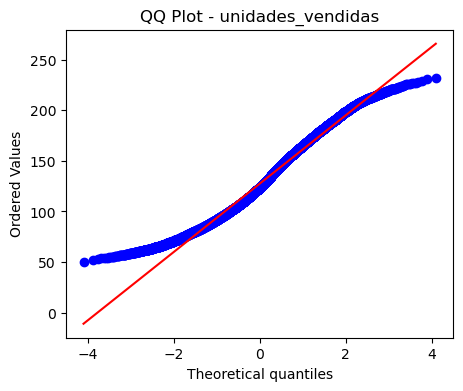

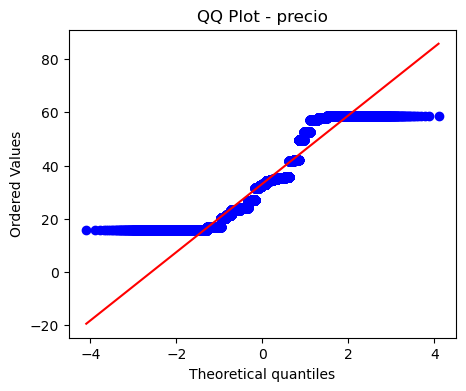

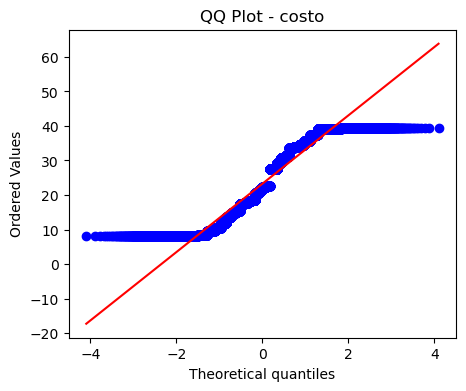

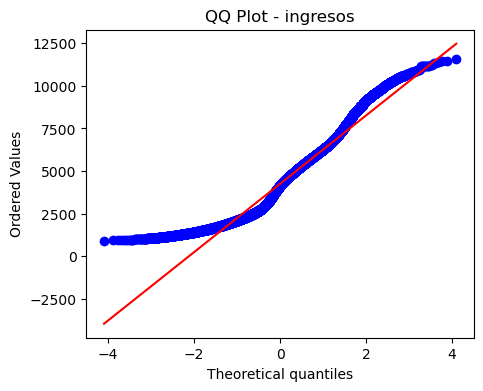

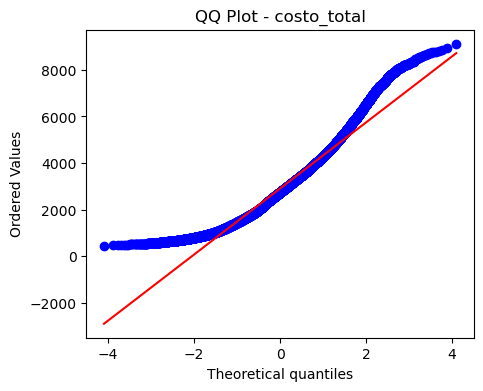

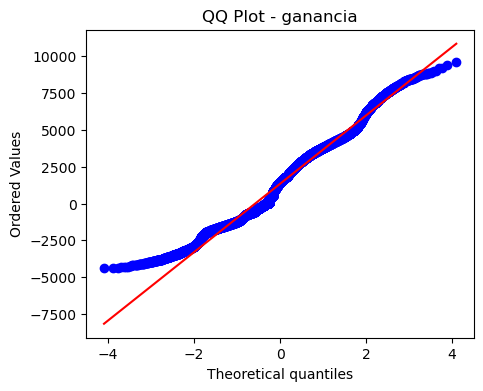

In [13]:
# ==========================================
# PRUEBA DE NORMALIDAD - VARIABLES CONTINUAS
# DATASET PHARMA
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro
import scipy.stats as stats

# Variables continuas del dataset pharma
variables_continuas = [
    "unidades_vendidas",
    "precio",
    "costo",
    "ingresos",
    "costo_total",
    "ganancia"
]

print("PRUEBA DE NORMALIDAD (Shapiro-Wilk)")
print("====================================\n")

resultados = []

for col in variables_continuas:
    
    # Shapiro es sensible a muestras grandes → usamos 500 observaciones
    sample = dataset[col].sample(500, random_state=42)
    
    stat, p_value = shapiro(sample)
    
    resultados.append([col, round(stat,4), round(p_value,4)])
    
    print(f"Variable: {col}")
    print(f"Estadístico W: {round(stat,4)}")
    print(f"p-value: {round(p_value,4)}")
    
    if p_value > 0.05:
        print("Conclusión: Compatible con normalidad\n")
    else:
        print("Conclusión: No sigue distribución normal\n")

# Convertir resultados a DataFrame
resultados_df = pd.DataFrame(resultados, columns=["Variable", "W", "p_value"])

print("\nResumen final:")
print(resultados_df)


# ==========================================
# QQ PLOTS (Verificación visual profesional)
# ==========================================

for col in variables_continuas:
    plt.figure(figsize=(5,4))
    stats.probplot(dataset[col], dist="norm", plot=plt)
    plt.title(f"QQ Plot - {col}")
    plt.show()

Los datos no poseen distribución Normal

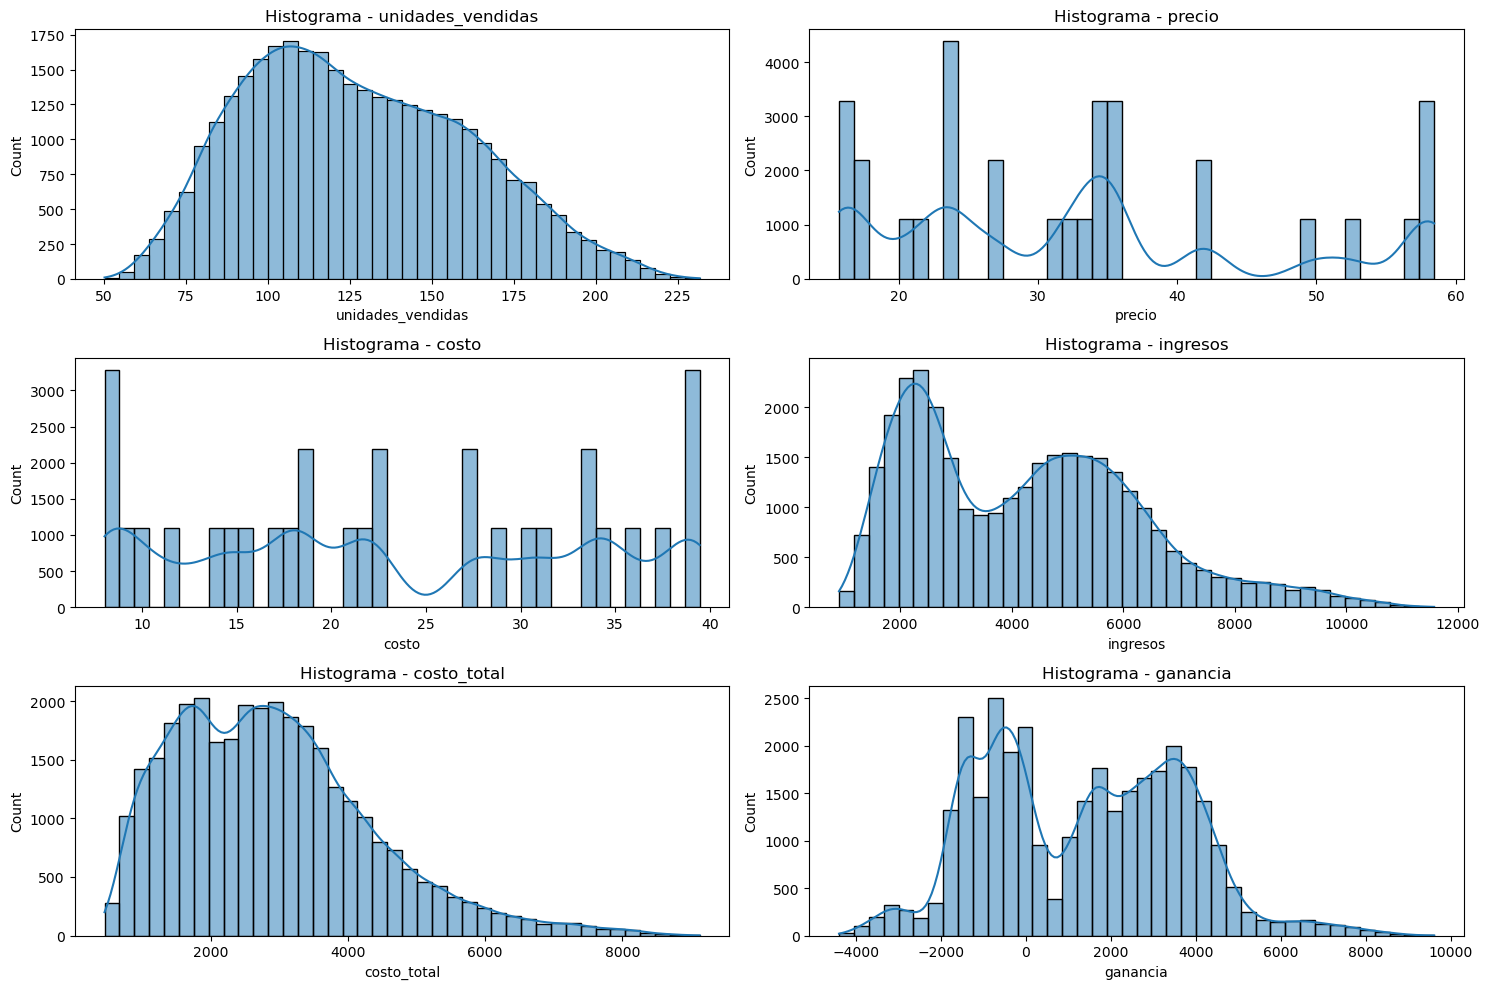

In [14]:
# ==========================================
# HISTOGRAMAS - VARIABLES CONTINUAS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

variables_continuas = [
    "unidades_vendidas",
    "precio",
    "costo",
    "ingresos",
    "costo_total",
    "ganancia"
]

plt.figure(figsize=(15,10))

for i, col in enumerate(variables_continuas, 1):
    plt.subplot(3, 2, i)
    sns.histplot(dataset[col], bins=40, kde=True)
    plt.title(f"Histograma - {col}")
    plt.tight_layout()

plt.show()

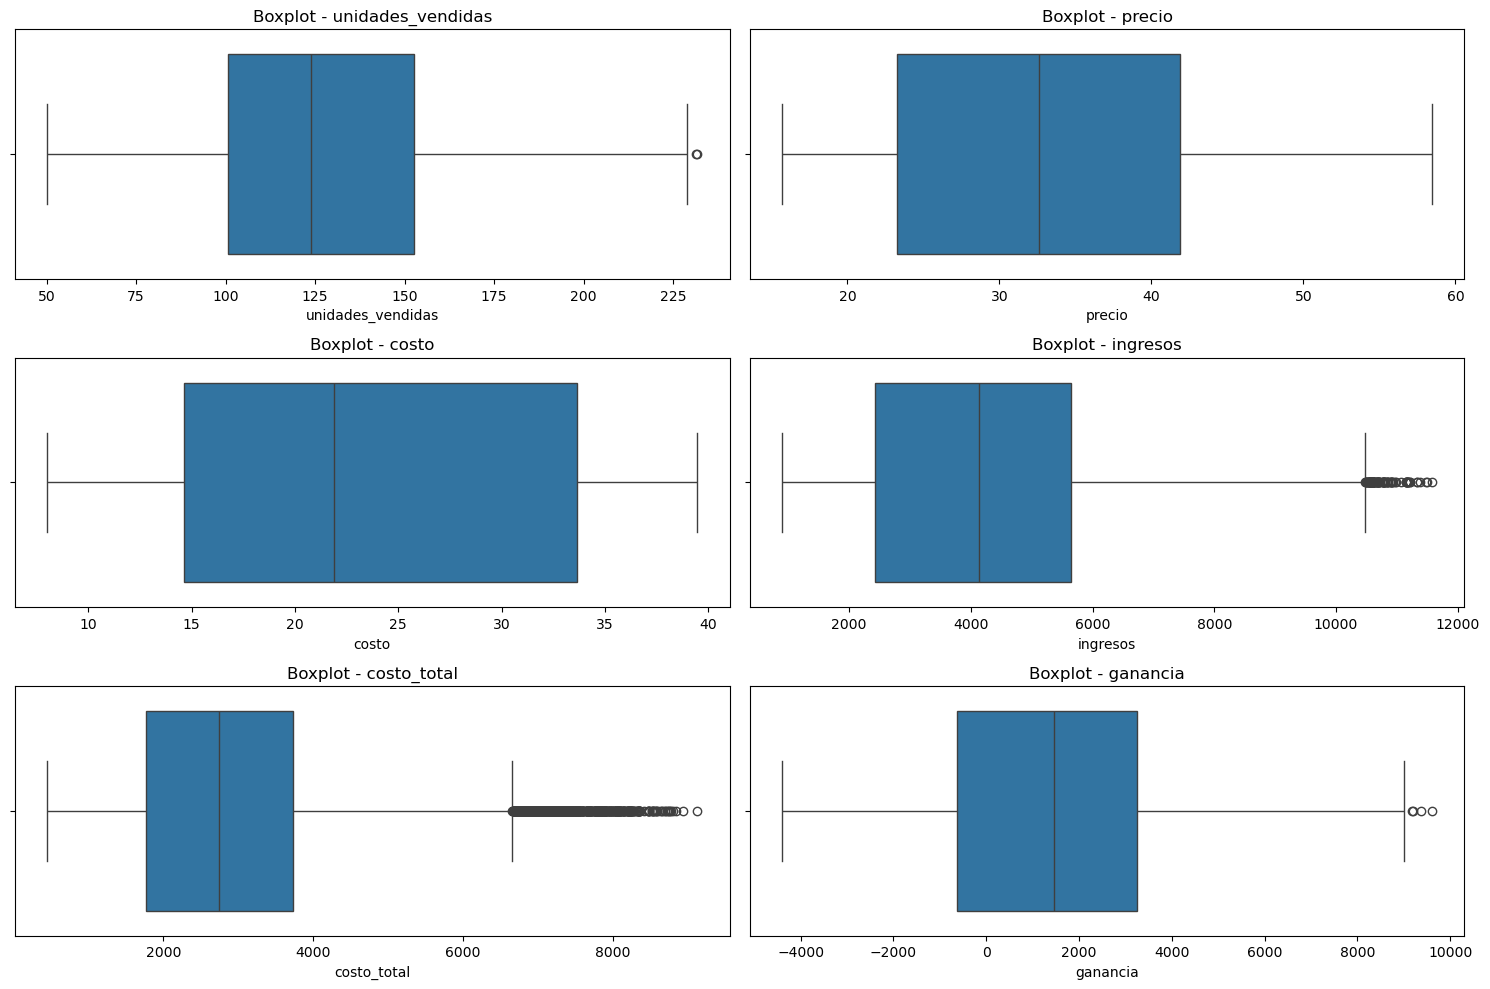

In [15]:
# ==========================================
# BOXPLOTS - VARIABLES CONTINUAS
# ==========================================

plt.figure(figsize=(15,10))

for i, col in enumerate(variables_continuas, 1):
    plt.subplot(3, 2, i)
    sns.boxplot(x=dataset[col])
    plt.title(f"Boxplot - {col}")
    plt.tight_layout()

plt.show()

In [16]:
# ==================================
# DETECCIÓN FORMAL DE OUTLIERS (IQR)
# ==================================

def detectar_outliers(col):
    Q1 = dataset[col].quantile(0.25)
    Q3 = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    outliers = dataset[(dataset[col] < limite_inferior) | 
                       (dataset[col] > limite_superior)]
    
    print(f"\nVariable: {col}")
    print("Cantidad de outliers:", len(outliers))
    print("Porcentaje:", round(len(outliers)/len(dataset)*100,2), "%")
    
    return outliers

out_ingresos = detectar_outliers("ingresos")
out_ganancia = detectar_outliers("ganancia")
out_unidades = detectar_outliers("unidades_vendidas")


Variable: ingresos
Cantidad de outliers: 95
Porcentaje: 0.29 %

Variable: ganancia
Cantidad de outliers: 4
Porcentaje: 0.01 %

Variable: unidades_vendidas
Cantidad de outliers: 2
Porcentaje: 0.01 %


In [17]:
out_ingresos[["fecha","categoria","laboratorio","unidades_vendidas","ingresos"]].sort_values("ingresos", ascending=False).head(10)

,fecha,categoria,laboratorio,unidades_vendidas,ingresos
13980,2025-04-08,Antialergico,Roemmers,198.031578,11575.627275
14000,2025-04-28,Antialergico,Roemmers,196.529460,11487.823291
13960,2025-03-19,Antialergico,Roemmers,196.283679,11473.456539
14015,2025-05-13,Antialergico,Roemmers,194.583703,11374.087072
13974,2025-04-02,Antialergico,Roemmers,193.872344,11332.505690
14008,2025-05-06,Antialergico,Roemmers,193.695176,11322.149660
14002,2025-04-30,Antialergico,Roemmers,191.831431,11213.207345
13995,2025-04-23,Antialergico,Roemmers,191.793479,11210.988896
13946,2025-03-05,Antialergico,Roemmers,191.333735,11184.115278
13967,2025-03-26,Antialergico,Roemmers,191.278803,11180.904292


Se identificaron 95 observaciones (0.29%) como outliers en ingresos bajo criterio IQR.
El análisis contextual mostró que corresponden a productos antialérgicos del laboratorio Roemmers en 2025, con altos volúmenes consistentes.
Se concluye que representan picos reales de demanda y no errores de datos.

Correlación Sperman (dataset grande)

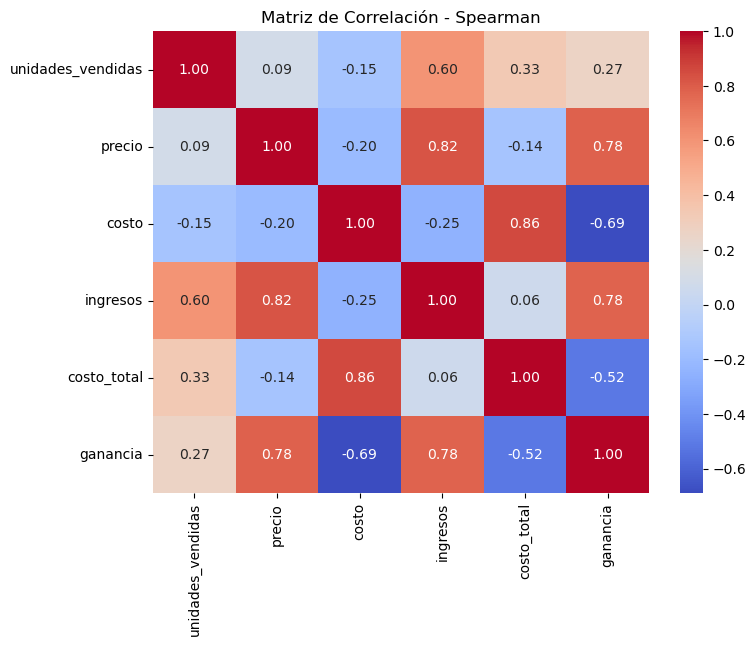

In [18]:
# ==========================================
# MATRIZ DE CORRELACIÓN - SPEARMAN
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt

variables_numericas = [
    "unidades_vendidas",
    "precio",
    "costo",
    "ingresos",
    "costo_total",
    "ganancia"
]

corr_spearman = dataset[variables_numericas].corr(method="spearman")

plt.figure(figsize=(8,6))
sns.heatmap(corr_spearman, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlación - Spearman")
plt.show()

La matriz de correlación de Spearman muestra que la ganancia está fuertemente asociada con el precio y los ingresos, mientras que presenta una relación negativa significativa con los costos. Esto sugiere que la rentabilidad del negocio depende principalmente de la estrategia de precios y del control de costos más que del volumen de ventas. Asimismo, las unidades vendidas presentan una correlación moderada con los ingresos, indicando que el crecimiento financiero no está impulsado exclusivamente por el aumento en ventas.

Evolución Temporal

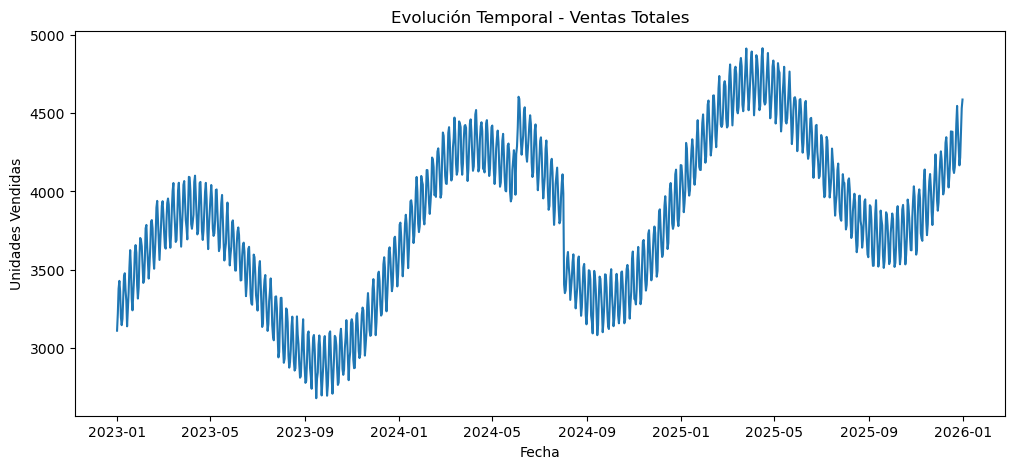

In [19]:
ventas_totales = dataset.groupby("fecha")["unidades_vendidas"].sum()

plt.figure(figsize=(12,5))
plt.plot(ventas_totales)
plt.title("Evolución Temporal - Ventas Totales")
plt.xlabel("Fecha")
plt.ylabel("Unidades Vendidas")
plt.show()

La serie temporal de ventas muestra una tendencia creciente sostenida entre 2023 y 2026, indicando expansión progresiva del volumen comercial. Se observa un patrón estacional anual bien definido, con ciclos recurrentes de aumento y disminución de ventas, lo que sugiere un comportamiento predecible de la demanda. Asimismo, se identifica una caída puntual a mediados de 2024 que podría asociarse a factores operativos o comerciales específicos. En general, el crecimiento estructural acompañado de estacionalidad indica un mercado en expansión con patrones de consumo recurrentes.

Estacionalidad Mensual

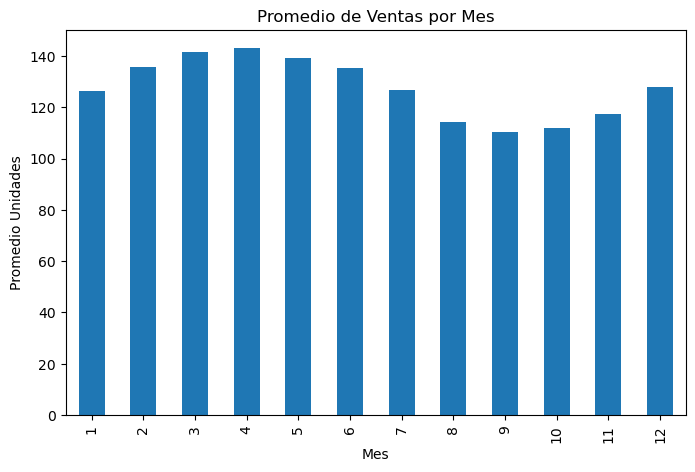

In [20]:
dataset["month"] = dataset["fecha"].dt.month

ventas_mes = dataset.groupby("month")["unidades_vendidas"].mean()

plt.figure(figsize=(8,5))
ventas_mes.plot(kind="bar")
plt.title("Promedio de Ventas por Mes")
plt.xlabel("Mes")
plt.ylabel("Promedio Unidades")
plt.show()

El análisis del promedio de ventas por mes evidencia un patrón estacional marcado, con un pico de demanda entre marzo y mayo y una disminución progresiva hasta alcanzar su mínimo en septiembre. Posteriormente, las ventas muestran una recuperación hacia el último trimestre del año. Este comportamiento confirma la existencia de ciclos anuales de consumo, lo que permite anticipar periodos de alta y baja demanda para optimizar estrategias comerciales y de inventario.

Ventas por Categoría

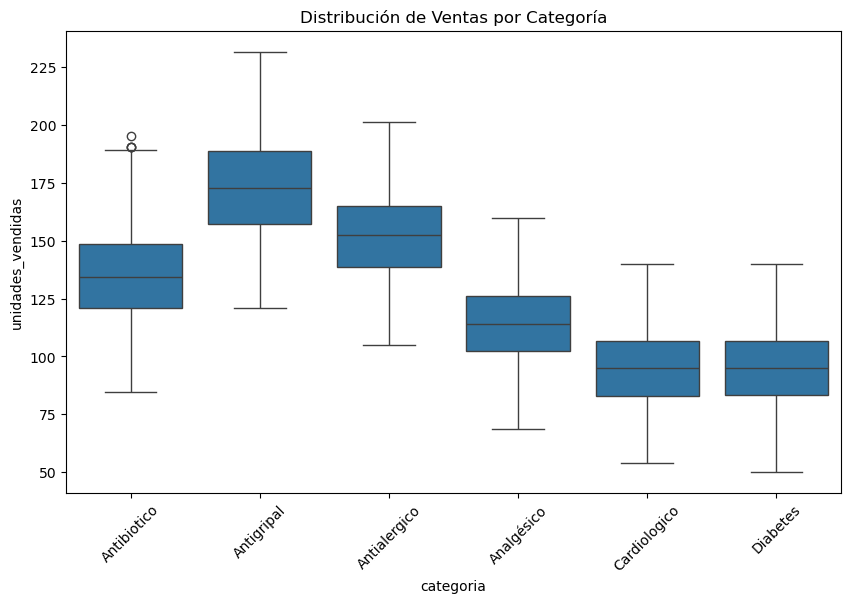

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(data=dataset, x="categoria", y="unidades_vendidas")
plt.xticks(rotation=45)
plt.title("Distribución de Ventas por Categoría")
plt.show()

El análisis de distribución de ventas por categoría evidencia diferencias significativas en los niveles de demanda. Los productos antigripales presentan la mayor mediana de ventas y mayor variabilidad, sugiriendo una fuerte influencia estacional. Las categorías antialérgica y antibiótica muestran altos niveles de rotación con comportamiento relativamente estable. En contraste, las categorías cardiológica y de diabetes presentan menores volúmenes pero una distribución más consistente, asociada probablemente a tratamientos crónicos y demanda sostenida.

Ingresos vs Unidades (Relación clave de negocio)

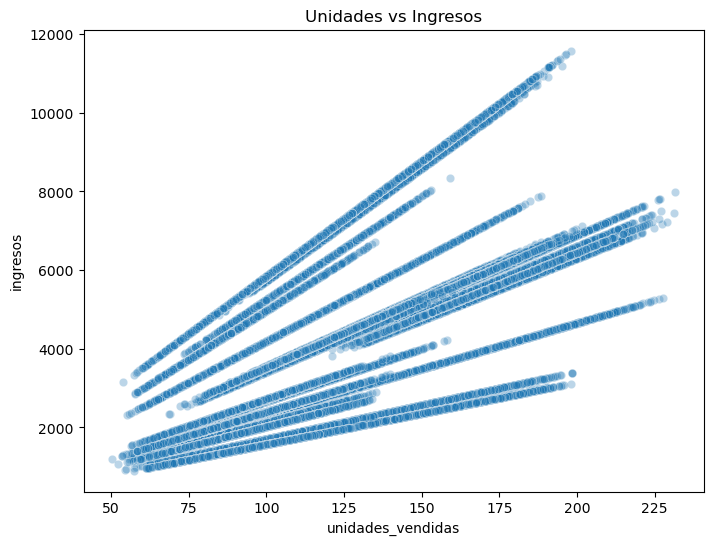

In [22]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=dataset, x="unidades_vendidas", y="ingresos", alpha=0.3)
plt.title("Unidades vs Ingresos")
plt.show()

El análisis de dispersión entre unidades vendidas e ingresos muestra una relación positiva altamente lineal, indicando que el crecimiento de ingresos está directamente asociado al volumen de ventas. La presencia de múltiples tendencias lineales paralelas sugiere la existencia de diferentes niveles de precios entre productos o categorías, reflejando una estrategia comercial basada en segmentación de valor.

Ganancia por Laboratorio

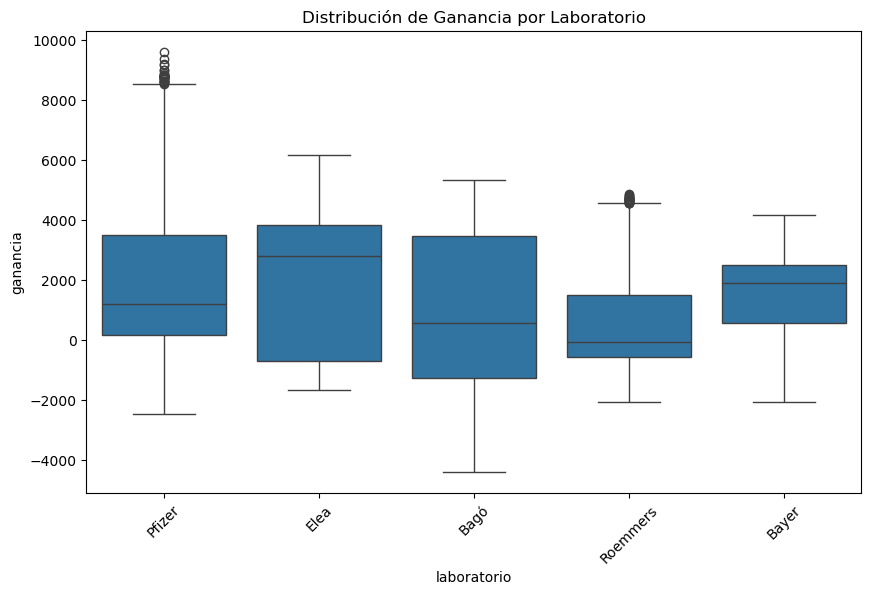

In [23]:
plt.figure(figsize=(10,6))
sns.boxplot(data=dataset, x="laboratorio", y="ganancia")
plt.xticks(rotation=45)
plt.title("Distribución de Ganancia por Laboratorio")
plt.show()

Conclusión para el cliente

Si hablamos en términos simples:

🏆 Elea y Bayer son las más estables y confiables.

📈 Pfizer puede generar ganancias muy altas, pero es más variable.

⚠️ Bagó y Roemmers presentan mayor riesgo o menor rentabilidad.

Pareto 80/20 – Impacto en Rentabilidad

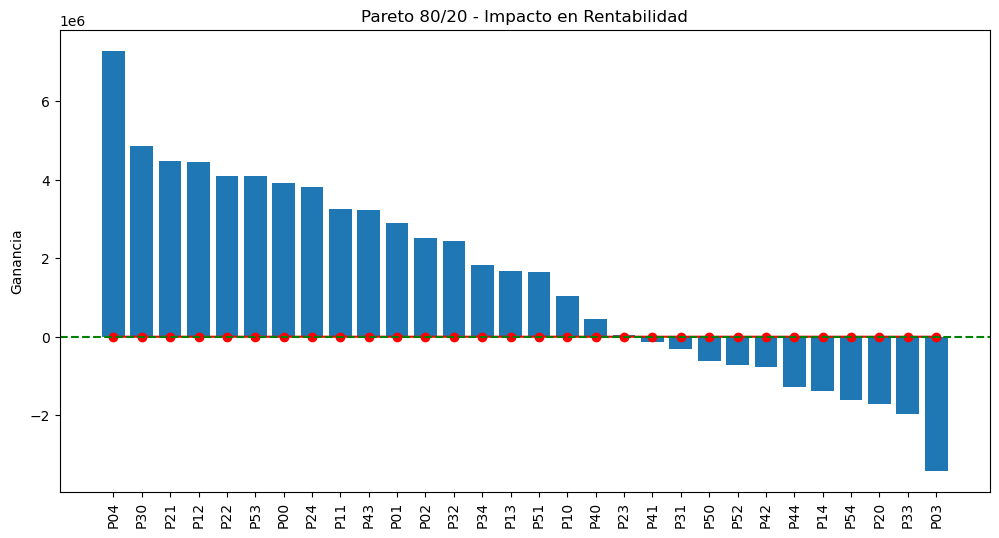

In [24]:
# ======================================
# PARETO DE GANANCIA POR PRODUCTO
# ======================================

abc = dataset.groupby("product_id")["ganancia"].sum().reset_index()
abc = abc.sort_values("ganancia", ascending=False)

abc["acumulado"] = abc["ganancia"].cumsum()
abc["porcentaje_acum"] = 100 * abc["acumulado"] / abc["ganancia"].sum()

plt.figure(figsize=(12,6))

plt.bar(abc["product_id"], abc["ganancia"])
plt.plot(abc["product_id"], abc["porcentaje_acum"], color="red", marker="o")

plt.xticks(rotation=90)
plt.ylabel("Ganancia")
plt.title("Pareto 80/20 - Impacto en Rentabilidad")
plt.axhline(80, color="green", linestyle="--")
plt.show()

Resumen ejecutivo:

La rentabilidad no está distribuida de forma uniforme: pocos productos generan la mayor parte de las ganancias, mientras otros están impactando negativamente los resultados.

Acción recomendada:
Enfocar recursos en los productos más rentables y revisar los que generan pérdidas (ajustar precios, reducir costos o evaluar su continuidad), aplicando un enfoque 80/20 para maximizar la rentabilidad.

Rentabilidad por Categoría

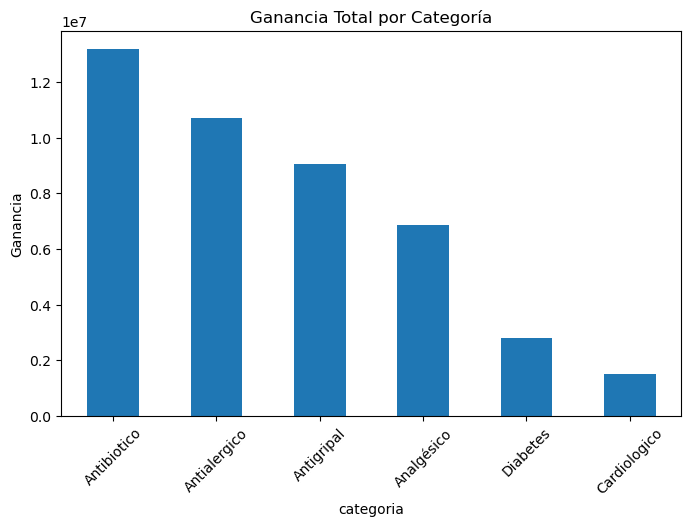

In [25]:
rent_cat = dataset.groupby("categoria")["ganancia"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
rent_cat.plot(kind="bar")
plt.title("Ganancia Total por Categoría")
plt.ylabel("Ganancia")
plt.xticks(rotation=45)
plt.show()

“La rentabilidad del negocio está fuertemente concentrada en antibióticos y antialérgicos. Potenciar estas categorías puede maximizar el crecimiento, mientras que las de menor rendimiento requieren revisión estratégica.”

Market Share por Laboratorio (Ingresos)

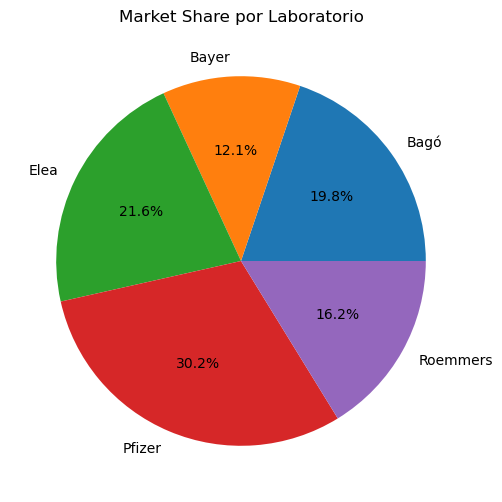

In [26]:
market_share = dataset.groupby("laboratorio")["ingresos"].sum()
market_share = 100 * market_share / market_share.sum()

plt.figure(figsize=(6,6))
market_share.plot(kind="pie", autopct="%1.1f%%")
plt.title("Market Share por Laboratorio")
plt.ylabel("")
plt.show()

“El mercado está liderado por Pfizer con el 30%, seguido por Elea y Bagó. La participación está relativamente distribuida, lo que indica un entorno competitivo con oportunidades de crecimiento para los laboratorios con menor cuota.”

Crecimiento Año contra Año

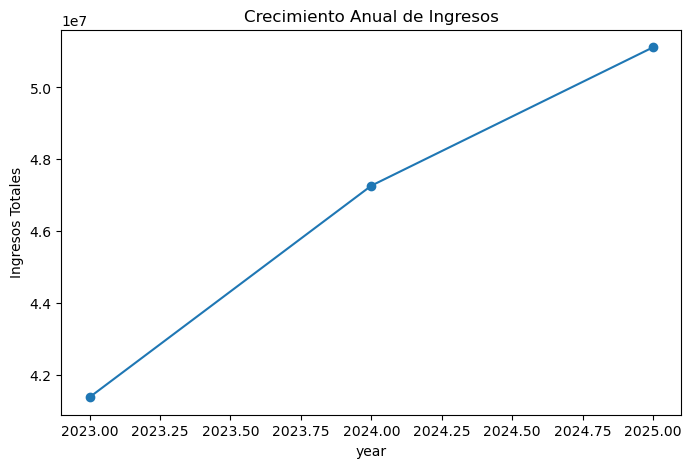

In [27]:
dataset["year"] = dataset["fecha"].dt.year

ventas_anuales = dataset.groupby("year")["ingresos"].sum()

plt.figure(figsize=(8,5))
ventas_anuales.plot(marker="o")
plt.title("Crecimiento Anual de Ingresos")
plt.ylabel("Ingresos Totales")
plt.show()

“Los ingresos muestran un crecimiento sostenido entre 2023 y 2025, lo que indica una tendencia positiva y una evolución favorable del negocio.”

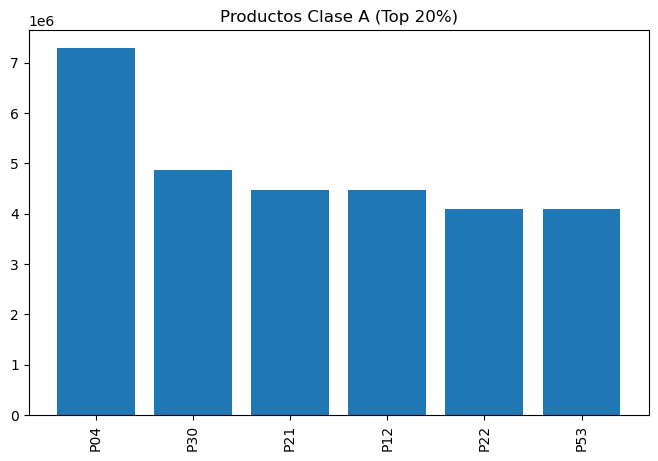

In [28]:
top_20 = abc.head(int(len(abc)*0.2))

plt.figure(figsize=(8,5))
plt.bar(top_20["product_id"], top_20["ganancia"])
plt.xticks(rotation=90)
plt.title("Productos Clase A (Top 20%)")
plt.show()

Estos son los productos que NO pueden quedarse sin stock.

Margen por Categoría

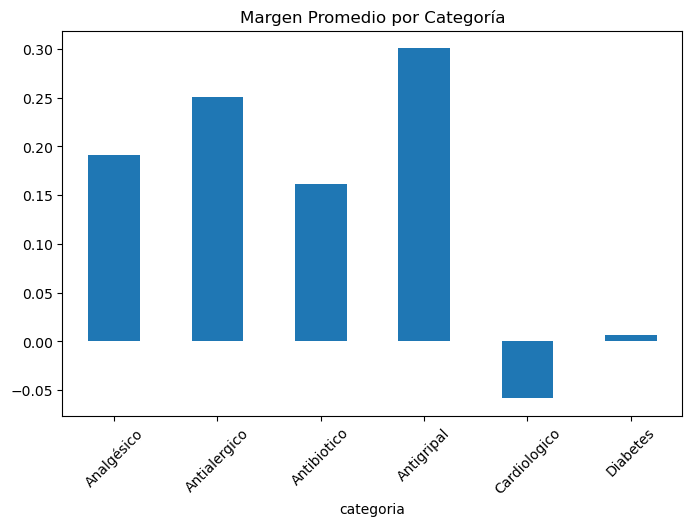

In [29]:
dataset["margen"] = dataset["ganancia"] / dataset["ingresos"]

margen_cat = dataset.groupby("categoria")["margen"].mean()

plt.figure(figsize=(8,5))
margen_cat.plot(kind="bar")
plt.title("Margen Promedio por Categoría")
plt.xticks(rotation=45)
plt.show()

No todo lo que vende mucho es rentable.

Riesgo – Productos con Baja Ganancia

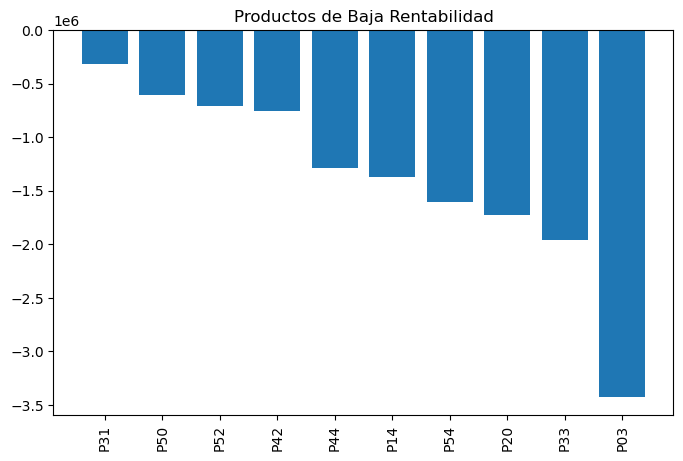

In [30]:
baja_ganancia = abc.tail(10)

plt.figure(figsize=(8,5))
plt.bar(baja_ganancia["product_id"], baja_ganancia["ganancia"])
plt.xticks(rotation=90)
plt.title("Productos de Baja Rentabilidad")
plt.show()

Candidatos para descontinuar.